In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("day.csv")

In [3]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
df.tail()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796
730,731,2012-12-31,1,1,12,0,1,1,2,0.215833,0.223487,0.577500,0.154846,439,2290,2729


In [4]:
df.shape

(731, 16)

In [5]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [8]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

In [8]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


# Data Cleaning

In [11]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

# Exploratory Data Analysis (EDA)

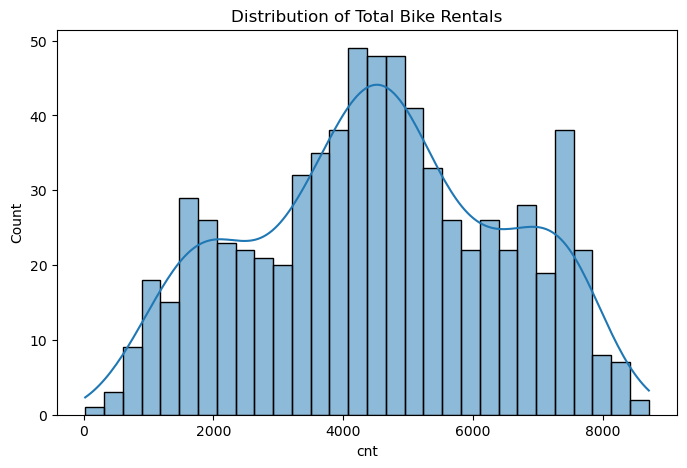

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribution of Total Bike Rentals")
plt.show()

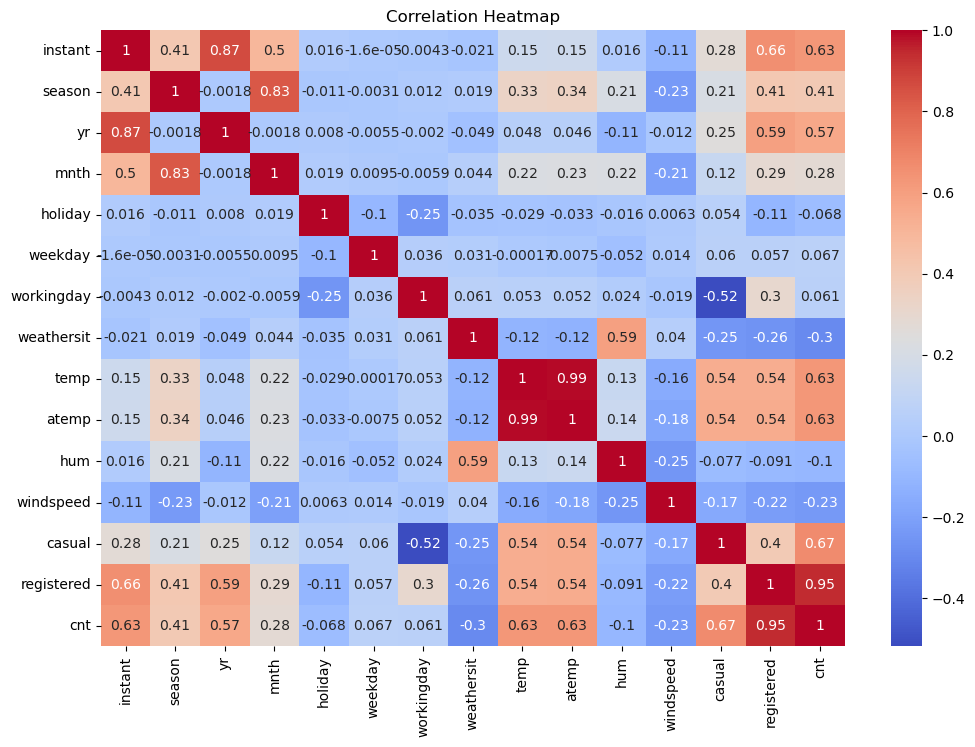

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

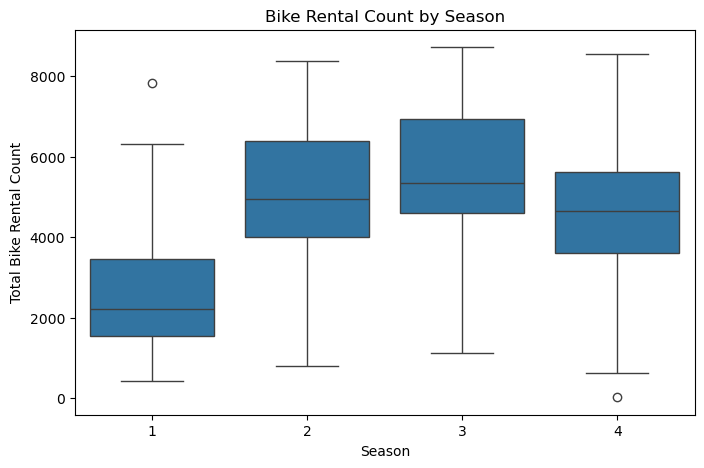

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='season', y='cnt', data=df)

plt.title("Bike Rental Count by Season")
plt.xlabel("Season")
plt.ylabel("Total Bike Rental Count")
plt.show()

Summer and Fall have higher bike rental counts, while Winter has lower rentals due to colder weather.

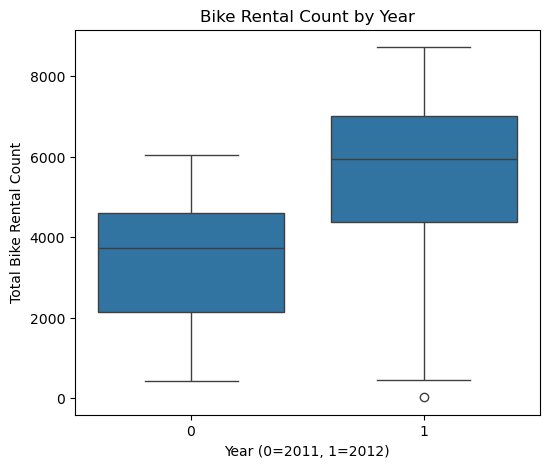

In [36]:
plt.figure(figsize=(6,5))
sns.boxplot(x='yr', y='cnt', data=df)

plt.title("Bike Rental Count by Year")
plt.xlabel("Year (0=2011, 1=2012)")
plt.ylabel("Total Bike Rental Count")
plt.show()

Bike rentals increased in 2012 compared to 2011, indicating growing popularity of the bike-sharing system.

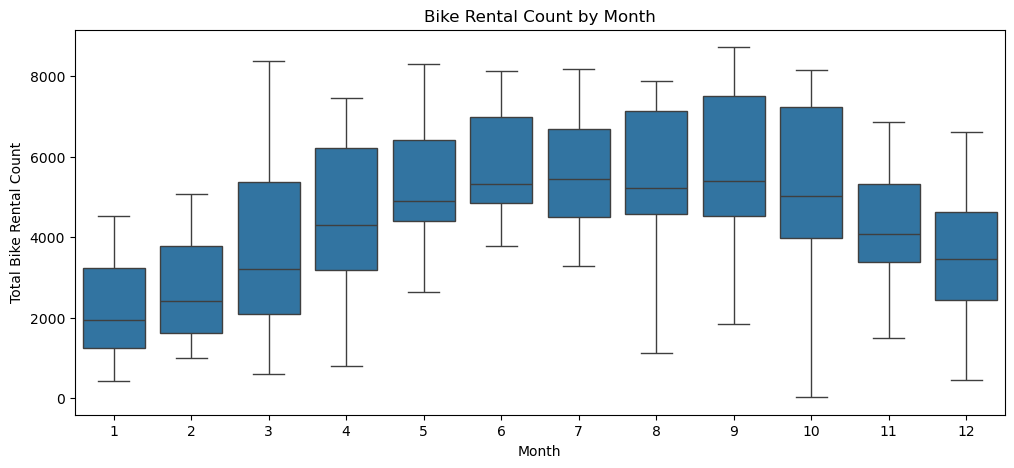

In [39]:
plt.figure(figsize=(12,5))
sns.boxplot(x='mnth', y='cnt', data=df)

plt.title("Bike Rental Count by Month")
plt.xlabel("Month")
plt.ylabel("Total Bike Rental Count")
plt.show()

Bike rental counts vary across months, with higher rentals during warmer months and lower rentals during colder months.

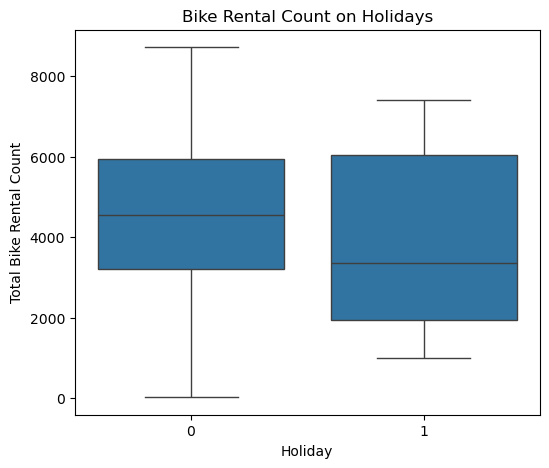

In [40]:
plt.figure(figsize=(6,5))
sns.boxplot(x='holiday', y='cnt', data=df)

plt.title("Bike Rental Count on Holidays")
plt.xlabel("Holiday")
plt.ylabel("Total Bike Rental Count")
plt.show()

Bike rentals are generally lower on holidays than on non-holidays.

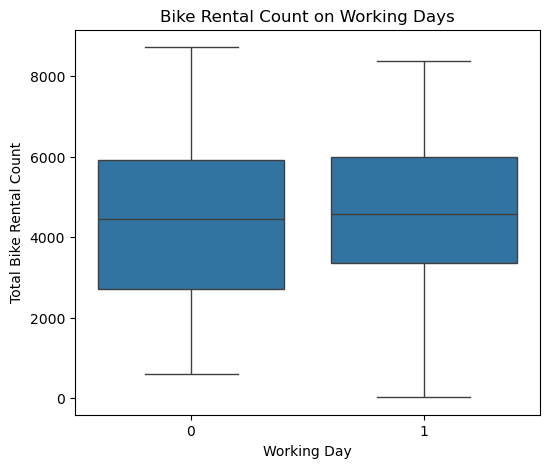

In [41]:
plt.figure(figsize=(6,5))
sns.boxplot(x='workingday', y='cnt', data=df)

plt.title("Bike Rental Count on Working Days")
plt.xlabel("Working Day")
plt.ylabel("Total Bike Rental Count")

plt.show()

Bike rentals are generally higher on working days, indicating that many users rent bikes for commuting.

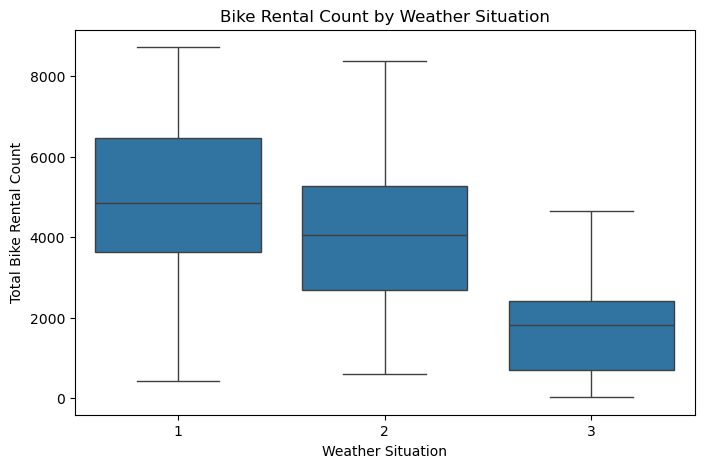

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='weathersit', y='cnt', data=df)

plt.title("Bike Rental Count by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Total Bike Rental Count")

plt.show()

Bike rentals are highest during clear weather and decrease as weather conditions become worse.

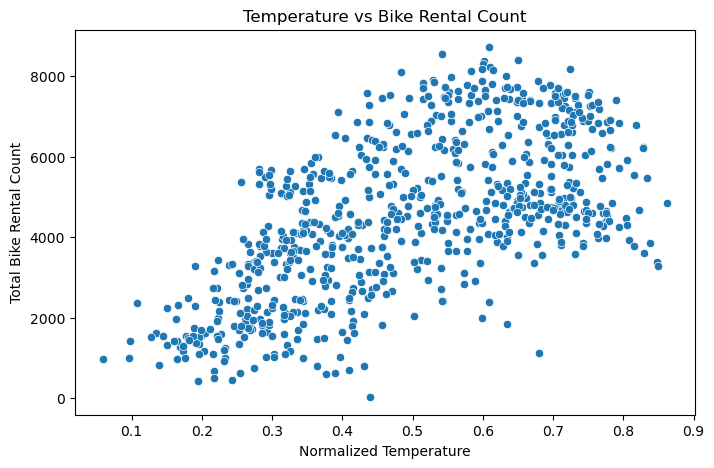

In [43]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='temp', y='cnt', data=df)

plt.title("Temperature vs Bike Rental Count")
plt.xlabel("Normalized Temperature")
plt.ylabel("Total Bike Rental Count")

plt.show()

As temperature increases, bike rental counts generally increase, showing a positive relationship.

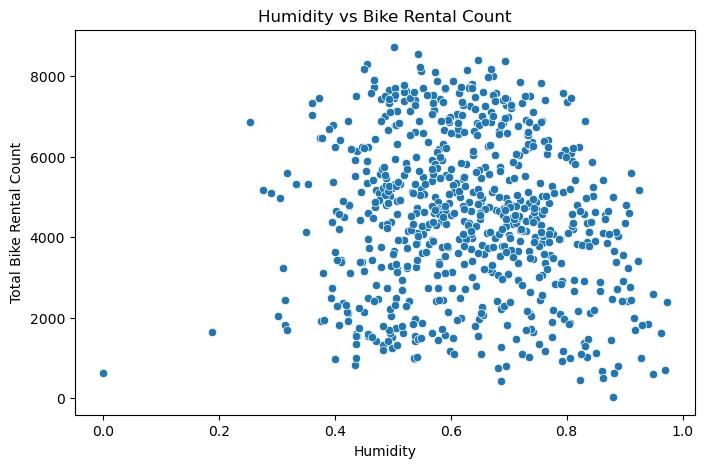

In [45]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='hum', y='cnt', data=df)

plt.title("Humidity vs Bike Rental Count")
plt.xlabel("Humidity")
plt.ylabel("Total Bike Rental Count")

plt.show()

Higher humidity is generally associated with lower bike rental counts, although the relationship is not very strong.

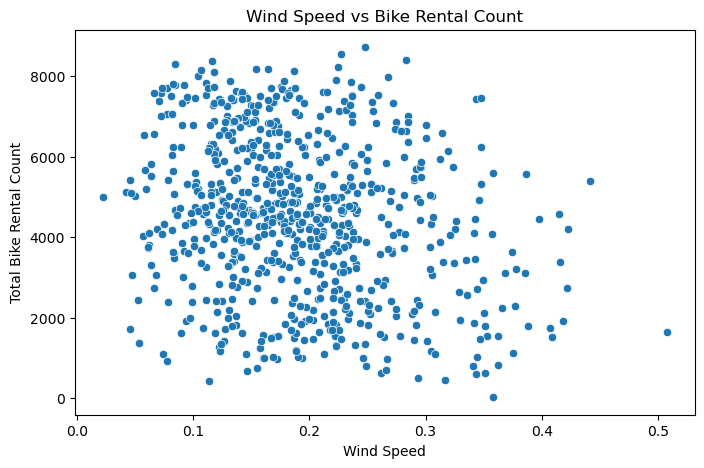

In [46]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='windspeed', y='cnt', data=df)

plt.title("Wind Speed vs Bike Rental Count")
plt.xlabel("Wind Speed")
plt.ylabel("Total Bike Rental Count")

plt.show()

Bike rental counts generally decrease as wind speed increases, indicating that strong winds may discourage people from renting bikes.

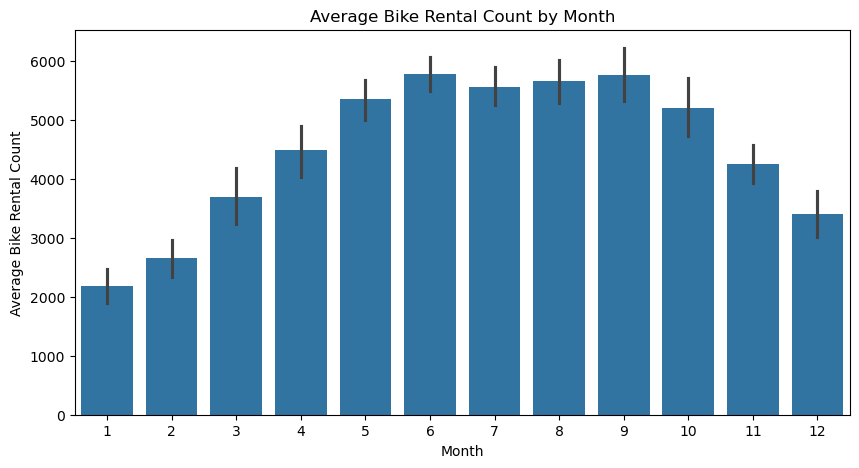

In [47]:
plt.figure(figsize=(10,5))
sns.barplot(x='mnth', y='cnt', data=df)

plt.title("Average Bike Rental Count by Month")
plt.xlabel("Month")
plt.ylabel("Average Bike Rental Count")

plt.show()

Average bike rentals are higher during the warmer months and lower during the colder months.

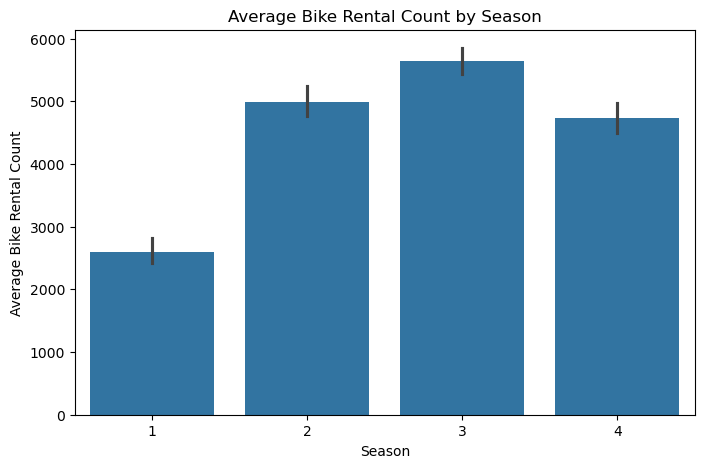

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(x='season', y='cnt', data=df)

plt.title("Average Bike Rental Count by Season")
plt.xlabel("Season")
plt.ylabel("Average Bike Rental Count")

plt.show()

Average bike rentals are higher during Summer and Fall, while Winter records the lowest average rentals.

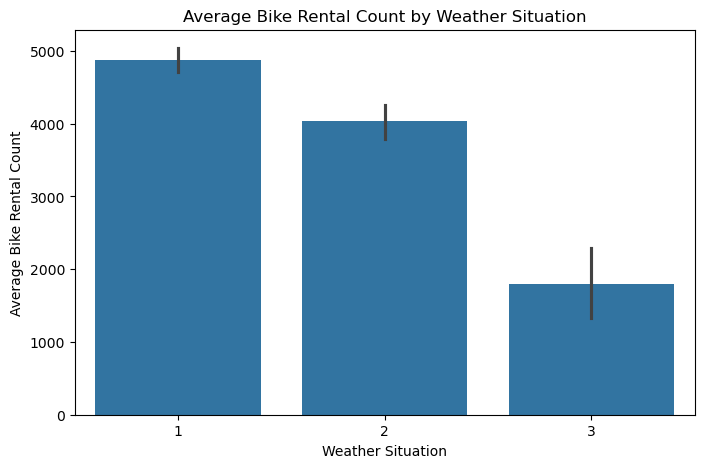

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(x='weathersit', y='cnt', data=df)

plt.title("Average Bike Rental Count by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Average Bike Rental Count")

plt.show()

Bike rentals are highest in clear weather and decrease significantly under poor weather conditions.

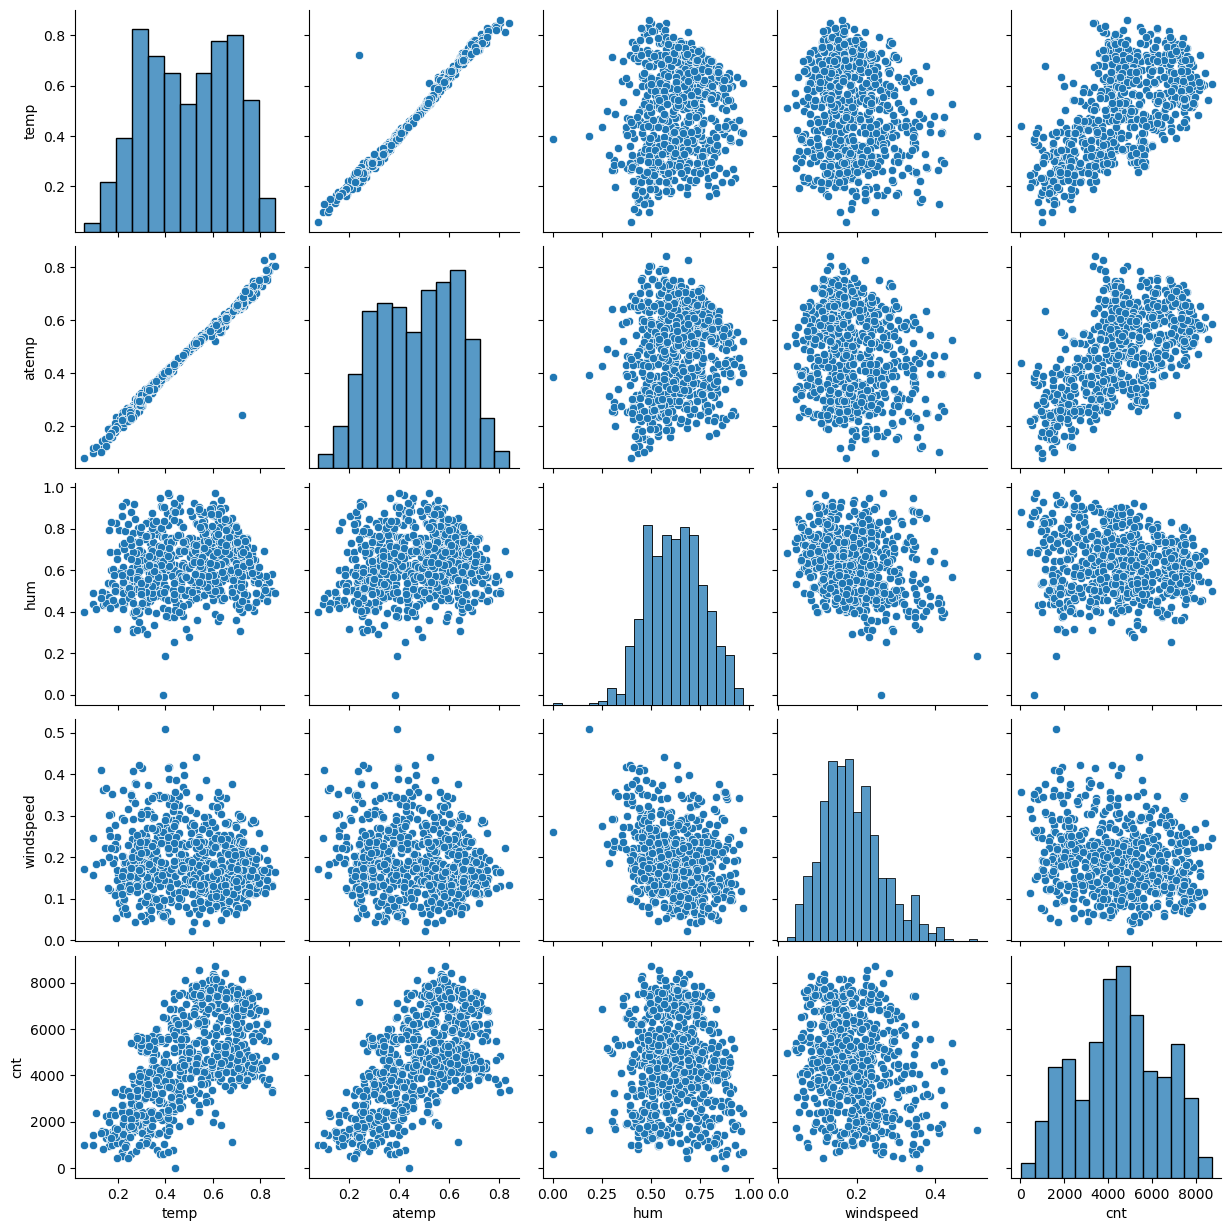

In [50]:
sns.pairplot(df[['temp','atemp','hum','windspeed','cnt']])
plt.show()

The pairplot shows the relationships between important numerical features. Temperature has a positive relationship with bike rentals, while humidity and wind speed show a weaker negative relationship.

In [14]:
df['dteday'] = pd.to_datetime(df['dteday'])

In [15]:
df['dteday'].dtype

dtype('<M8[ns]')

In [16]:
X = df.drop(['instant','dteday','casual','registered','cnt'], axis=1)
y = df['cnt']

In [17]:
X.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
lr_pred = lr.predict(X_test)

In [21]:
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

MAE: 617.3930656443374
MSE: 691035.0082022649
RMSE: 831.2851545662685
R2 Score: 0.8276670090367213


In [22]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [23]:
dt_pred = dt.predict(X_test)

In [24]:
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("MSE:", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score:", r2_score(y_test, dt_pred))

MAE: 662.8027210884354
MSE: 968219.2653061225
RMSE: 983.9813338199676
R2 Score: 0.7585417237651239


In [25]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
rf_pred = rf.predict(X_test)

In [27]:
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 435.8416140875846
MSE: 481582.2566519984
RMSE: 693.9612789284416
R2 Score: 0.8799011487137386


In [28]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("MAE:", mean_absolute_error(y_test, gb_pred))
print("MSE:", mean_squared_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2 Score:", r2_score(y_test, gb_pred))

MAE: 462.77011755459665
MSE: 438669.7456876681
RMSE: 662.3214821275753
R2 Score: 0.8906028371614286


In [31]:
ab = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

ab.fit(X_train, y_train)

ab_pred = ab.predict(X_test)

print("MAE:", mean_absolute_error(y_test, ab_pred))
print("MSE:", mean_squared_error(y_test, ab_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ab_pred)))
print("R2 Score:", r2_score(y_test, ab_pred))

MAE: 671.5514546027039
MSE: 791268.6266922525
RMSE: 889.53281372429
R2 Score: 0.8026703604379923


In [32]:
comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost"
    ],

    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
        r2_score(y_test, ab_pred)
    ],

    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred),
        mean_absolute_error(y_test, ab_pred)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred)),
        np.sqrt(mean_squared_error(y_test, ab_pred))
    ]

})

comparison.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,MAE,RMSE
3,Gradient Boosting,0.890603,462.770118,662.321482
2,Random Forest,0.879901,435.841614,693.961279
0,Linear Regression,0.827667,617.393066,831.285155
4,AdaBoost,0.802670,671.551455,889.532814
1,Decision Tree,0.758542,662.802721,983.981334


In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

       Feature  Importance
7         temp    0.356910
1           yr    0.287206
8        atemp    0.149487
9          hum    0.056760
0       season    0.055726
10   windspeed    0.029149
2         mnth    0.027391
6   weathersit    0.016361
4      weekday    0.015633
5   workingday    0.004621
3      holiday    0.000755


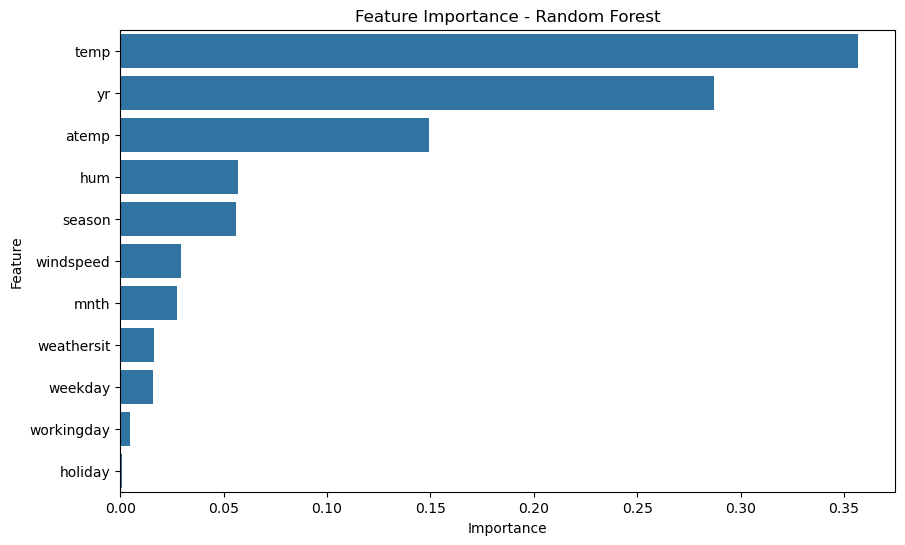

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

# Best Model for Production

Five regression models were developed and evaluated:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor
4. Gradient Boosting Regressor
5. AdaBoost Regressor

Based on the model comparison, the Gradient Boosting Regressor achieved the highest R² Score of **0.8906** with a low RMSE of **662.32**. Therefore, it is selected as the best model for production because it provides the most accurate prediction of daily bike rental counts.

# Challenges Faced

1. The dataset contained multiple environmental and seasonal factors affecting bike rental demand.

2. Identifying the most relevant features required careful exploratory data analysis.

3. Multiple regression models were trained and compared to determine the best-performing model.

4. Balancing prediction accuracy while avoiding overfitting was an important challenge.

5. Model performance was evaluated using R² Score and RMSE to select the most suitable model for production.

## Conclusion


This project successfully analyzed the factors influencing daily bike rental demand and developed machine learning models to predict rental counts. Five regression models were trained and evaluated using R² Score and RMSE. Among them, the Gradient Boosting Regressor achieved the best performance with an R² Score of **0.8906** and an RMSE of **662.32**, making it the most suitable model for production. The developed model can help bike-sharing companies improve demand forecasting, optimize bike availability, and support better operational planning.